============================================= Markov Decision Process (MDP) =============================================

#### Markov Decision Process (MDP)

This section introduces the foundation of reinforcement learning: **Markov Decision Processes (MDPs)**. MDPs are mathematical models used to describe how systems evolve over time under a sequence of decisions. They form the basis for defining RL problems and later solution methods like Value Iteration and Q-Learning. 

##### Definition of an MDP

A **Markov Decision Process (MDP)** is a tuple: $\text{MDP}: (\mathcal{S}, \mathcal{A}, T, r)$

Where:

- **$\mathcal{S}$** — set of *states* the agent can be in (e.g., positions in a gridworld).  
- **$\mathcal{A}$** — set of *actions* the agent can take at each state.  
- **$T: \mathcal{S} \times \mathcal{A} \times \mathcal{S} \to [0,1]$** — *transition function* (probability distribution): $$T(s, a, s') = P(s_{t+1}=s' \mid s_t=s, a_t=a)$$
  This encodes how likely it is to move to state $s'$ after taking action $a$ in state $s$.

  So in an MDP, even when the current state $s$ and action $a$ are fixed, the next state $s'$ is generally **not deterministic**. Instead, the environment transitions according to above probability distribution.
- **$r: \mathcal{S} \times \mathcal{A} \to \mathbb{R}$** — *reward function*: immediate reward received when taking action $a$ in state $s$.  
  Larger rewards indicate more desirable actions relative to the task.
  
  when the current state $s$ and action $a$ are fixed, d2l assume the reward is fixed, but no necessary ot fixed in the most general MDP definition.

##### Return and Discount Factor

A **trajectory** in an MDP is a sequence generated by interacting with the environment:

$$
\tau = (s_0, a_0, r_0, s_1, a_1, r_1, s_2, a_2, r_2, \dots)
$$

- **Return** of a trajectory is the sum of rewards obtained along it:
  $R(\tau) = r_0 + r_1 + r_2 + \cdots$

- To handle potentially infinite trajectories and emphasize near-term rewards, we introduce a **discount factor** $\gamma < 1$:

  $
  R(\tau) = r_0 + \gamma r_1 + \gamma^2 r_2 + \cdots = \sum_{t=0}^\infty \gamma^t r_t
  $

  - Smaller $\gamma$ biases the agent toward near-term rewards.  
  - Larger $\gamma$ (close to 1) encourages long-term planning.

The **goal in reinforcement learning** is to *find the trajectory (policy) that maximizes expected return*.

##### Discussion of the Markov Assumption

The **Markov property** means the next state depends *only* on the current state and action — not on any earlier history.

##### Why this matters

- A process is **not Markov** only when the chosen state representation is missing information needed to predict the next state/reward.
- Example: if state is only position, dynamics with inertia are not Markov (next position depends on hidden velocity/history).
- If state includes both position and velocity, the same system can be Markov because $(s_t, a_t)$ is then sufficient to predict the next-step distribution.
- In practice, we often *augment* the state with such missing variables so the Markov assumption is a good approximation.

This assumption simplifies modeling and algorithms, and most RL techniques rely on it. 

##### Summary

- An MDP is a formal way to represent **sequential decision making under uncertainty**.  
- Defined by states, actions, transition probabilities, and rewards.  
- The objective is to choose actions that maximize *expected discounted return*.  
- Markov property simplifies modeling by assuming the future depends only on the current state and action. 

##### Additional Notes

- MDPs are the backbone of RL algorithms like Value Iteration and Q-Learning.
- In full RL problems, the agent often **doesn’t know** the exact transition function; it must learn optimal actions from experience. 

==================================== Value Iteration ====================================

### Value Iteration

This section introduces **Value Iteration**, a dynamic programming method for computing the **optimal value function** in a Markov Decision Process (MDP). It is one of the foundational algorithms in reinforcement learning when the environment model (transition and reward functions) is known.

#### Stochastic Policy

In an MDP, a **stochastic policy** $\pi(a|s)$ defines a probability distribution over actions $a \in \mathcal{A}$ for each state $s \in \mathcal{S}$. The goal is to find a policy that maximizes cumulative rewards.

#### Value Function

The **value function** $V^\pi(s)$ estimates the expected *discounted return* starting from state $s$ when following policy $\pi$.

#### Action-Value Function

The **action-value function** $Q^\pi(s,a)$ gives the expected return starting from state $s$, taking action $a$, and thereafter following policy $\pi$.

#### Optimal Stochastic Policy

An **optimal policy** $\pi^*$ maximizes the expected return for all states — and corresponds to the **optimal value function** $V^*(s)$.

#### Principle of Dynamic Programming

Value iteration uses the **Bellman Optimality Equation**:

$$
V^*(s) = \max_{a\in \mathcal{A}} \left\{r(s,a) + \gamma \sum_{s'\in \mathcal{S}} P(s'|s,a)\,V^*(s') \right\}
$$

This identity expresses that the best return from $s$ equals the best immediate action value plus the discounted value of successor states. It’s derived from the **principle of dynamic programming** — optimal substructure: *the remainder of an optimal trajectory is also optimal*.

#### Value Iteration Algorithm

##### Core Idea

Value iteration treats the Bellman Optimality Equation as a set of constraints and iteratively updates the value function until convergence.
##### Update Rule

Initialize the value function $V_0(s)$ arbitrarily (e.g., zero for all $s$). Then at iteration $k$, update:

$$
V_{k+1}(s)
= \max_{a\in \mathcal{A}}\Big\{r(s,a)
+ \gamma \sum_{s'\in \mathcal{S}}P(s'\mid s,a)\,V_k(s')\Big\},\quad \forall s\in \mathcal{S}.
$$

Continue until the values converge (changes between iterations are negligible).

##### Convergence

As $k\rightarrow \infty$, the sequence $\{V_k\}$ converges to the **optimal value function** $V^*$ regardless of initialization: $V^*(s) = \lim_{k\to\infty} V_k(s)\quad \forall s.$

Once $V^*$ is found, the corresponding **optimal policy** $\pi^*$ can be extracted by choosing actions that maximize the value at each state:

$$
\pi^*(s) = \arg\max_{a\in\mathcal{A}} \left\{
r(s,a) + \gamma \sum_{s'}P(s'|s,a)\,V^*(s')
\right\}.
$$

#### Policy Evaluation & Improvement (Implicit)

A simple way to think about the two terms is:
- **Evaluation**: "If I take action $a$ now, how good is that?"
- **Improvement**: "Among all actions, which one looks best?"

In **Policy Iteration**, these are done in separate blocks:
- First evaluate a fixed policy (compute its value function).
- Then improve the policy by choosing greedy actions from those values.

In **Value Iteration**, both happen together in one update:
$$
V_{k+1}(s)=\max_{a}\left[r(s,a)+\gamma\sum_{s'}P(s'|s,a)V_k(s')\right].
$$
How to read this equation:
- Inside the brackets, for each action $a$, we estimate its one-step return plus discounted future value (this is a one-step evaluation).
- The $\max_a$ then picks the best action immediately (this is improvement).

So instead of "evaluate policy fully, then improve", value iteration does "evaluate each action one step, then improve" at every state and every sweep.

#### Implementation of Value Iteration

In this notebook, implementation is model-based and uses the known transition table $P(s'|s,a)$ from FrozenLake.

- Initialize $V_0(s)=0$ for all states.
- For each sweep $k$, compute Bellman backups for every state-action pair and then set $V_k(s)=\max_a Q_k(s,a)$.
- Extract the greedy policy with $\pi_k(s)=\arg\max_a Q_k(s,a)$ after each sweep.
- Repeat for a fixed number of sweeps (`num_iters`) and visualize how $V_k$ and $\pi_k$ evolve.

A practical implementation may also stop early when the maximum value change is below a threshold $\theta$.

In [1]:
# FrozenLake setup cell.
# Environment story: a robot starts at S on a 4x4 grid and must reach goal G.
# Grid symbols: F=frozen safe cell, H=hole (failure/terminal), G=goal (+1 reward).
# Actions are discrete moves: left, down, right, up.
# Purpose: create a reproducible tabular MDP and expose its transition table
# so model-based Value Iteration and model-free Q-Learning can share one env_info API.
%matplotlib inline
import random
import numpy as np
import gymnasium as gym
from d2l import torch as d2l

# Global experiment settings used in the value-iteration section.
seed = 0  # Random number generator seed
gamma = 0.95  # Discount factor
num_iters = 10  # Number of Bellman update sweeps
random.seed(seed)  # Set Python RNG seed for reproducibility
np.random.seed(seed)  # Set NumPy RNG seed for reproducibility

def make_frozen_lake_env(seed):
    """Create FrozenLake environment and package MDP metadata for algorithms."""
    env = gym.make('FrozenLake-v1', is_slippery=False)
    env.reset(seed=seed)
    env.action_space.seed(seed)

    num_states = env.observation_space.n
    num_actions = env.action_space.n

    # Build env_info dictionary compatible with D2L helpers and our loops.
    env_info = {
        'env': env,
        'desc': env.unwrapped.desc,  # Grid layout (S/F/H/G) for visualization
        'num_states': num_states,
        'num_actions': num_actions,
        # Transition model: mdp[s][a] = [(prob, next_s, reward, terminated), ...]
        'mdp': env.unwrapped.P,
        'trans_prob_idx': 0,  # Tuple index for transition probability
        'nextstate_idx': 1,   # Tuple index for next state
        'reward_idx': 2,      # Tuple index for reward
    }

    return env_info

# Create deterministic FrozenLake environment.
env_info = make_frozen_lake_env(seed)
print(f"Number of states: {env_info['num_states']}, Number of actions: {env_info['num_actions']}")

Number of states: 16, Number of actions: 4


Transition tuple indices: prob=0, nextstate=1, reward=2


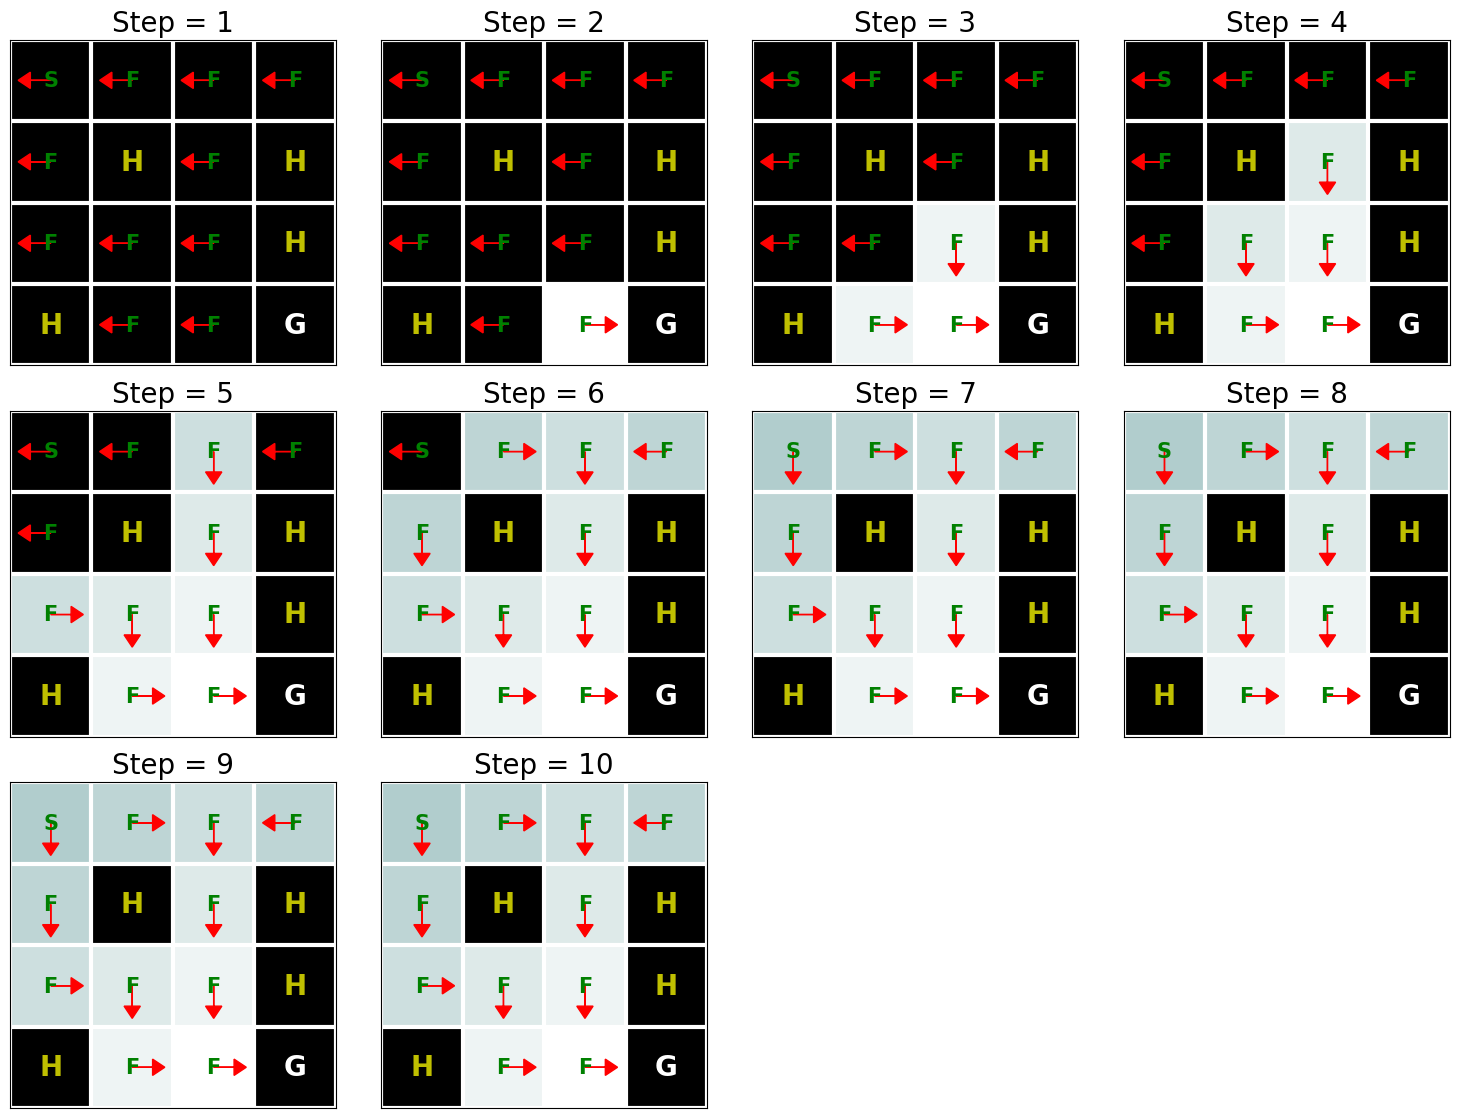

In [ ]:
# Value Iteration:

# Background: when the full MDP model is known (transition probabilities + rewards),
# we can compute the optimal policy via dynamic programming instead of trial-and-error.
 
# Problem to solve: for every state s, find the optimal value V*(s) and greedy action pi*(s).
# Core idea: repeatedly apply Bellman optimality backups until values stabilize:
# V_{k+1}(s) = max_a sum_{s'} p(s'|s,a) [r(s,a,s') + gamma * V_k(s')].
# This function implements those backups and visualizes V_k / pi_k progress over iterations.
def value_iteration(env_info, gamma, num_iters):
    # Extract MDP components needed by the Bellman optimality backup.
    env_desc = env_info['desc']  # Grid description for plotting only
    # These are field indices for each transition tuple in mdp[s][a].
    # Here each tuple is (probability, next_state, reward, done).
    prob_idx = env_info['trans_prob_idx'] # = 0
    nextstate_idx = env_info['nextstate_idx'] # = 1
    reward_idx = env_info['reward_idx'] # = 2
    print(f"Transition tuple indices: prob={prob_idx}, nextstate={nextstate_idx}, reward={reward_idx}")
    num_states = env_info['num_states']
    num_actions = env_info['num_actions']
    mdp = env_info['mdp']

    # Store full optimization trajectory: V_k, Q_k, and greedy policy pi_k.
    V = np.zeros((num_iters + 1, num_states))
    Q = np.zeros((num_iters + 1, num_states, num_actions))
    pi = np.zeros((num_iters + 1, num_states))

    # Each outer loop applies one synchronous Bellman optimality update.
    for k in range(1, num_iters + 1):
        for s in range(num_states):
            for a in range(num_actions):
                # Bellman backup for Q_k(s,a):
                # sum_{s'} p(s'|s,a) * [r(s,a,s') + gamma * V_{k-1}(s')]
                # Gym's transition table is indexed as mdp[s][a].
                for pxrds in mdp[s][a]:
                    # For fixed (s, a), mdp[s][a] is a list of (prob, next_state, reward, done)
                    # transitions; probabilities across this list sum to 1 (up to float rounding).
                    pr = pxrds[prob_idx]
                    nextstate = pxrds[nextstate_idx]
                    reward = pxrds[reward_idx]
                    Q[k, s, a] += pr * (reward + gamma * V[k - 1, nextstate])
            # Greedy improvement step after evaluating all actions at state s.
            V[k, s] = np.max(Q[k, s, :])
            pi[k, s] = np.argmax(Q[k, s, :])

    # Visualize convergence of value function and greedy policy over iterations.
    d2l.show_value_function_progress(env_desc, V[:-1], pi[:-1])

value_iteration(env_info=env_info, gamma=gamma, num_iters=num_iters)

====================================== Q-Learning ======================================

### Q-Learning

In the previous section we saw **Value Iteration**, which requires knowing the full **Markov Decision Process (MDP)** — specifically the transition and reward functions.  
**Q-Learning** (Watkins & Dayan, 1992) is a **model-free reinforcement learning algorithm** that learns action values from data collected by interacting with the environment, without requiring full knowledge of the MDP. 

#### The Q-Learning Algorithm

Recall the **value iteration update** for the action-value function:

$$
Q_{k+1}(s,a)
= r(s,a)
+ \gamma \sum_{s'\in\mathcal{S}} P(s'|s,a)\max_{a'\in\mathcal{A}}Q_k(s',a')
$$

Implementing this exactly requires knowing the transitions $P(s'|s,a)$.  
**Q-Learning replaces this expectation with samples** gathered by the agent interacting with the environment — in other words, the robot “gets its own data” rather than relying on a model.

The core idea is that as the agent collects transitions $(s_t,a_t,r_t,s_{t+1})$, it updates its estimate of the optimal action-value function using samples instead of summation over the full state space.

#### Optimization Perspective Underlying Q-Learning

Imagine the agent collects a dataset of $n$ trajectories of length $T$ using some exploration policy $\pi_e(a|s)$. The dataset is:

$\{(s^i_t,a^i_t,r^i_t,s^i_{t+1}) \}_{i=1..n, t=0..T-1}$

Note: the agent does NOT know the reward function in advance, but it DOES observe rewards when interacting with the environment.
We can frame Q-Learning as minimizing the **temporal-difference error** over this dataset:

$$
\hat{Q}
= \arg\min_Q
\frac{1}{nT}\sum_{i,t}
\Big(
Q(s^i_t,a^i_t)
- \Big[r(s^i_t,a^i_t)
+ \gamma \max_{a'} Q(s^i_{t+1},a')\Big]
\Big)^2
$$

When $Q$ is updated via gradient descent on this loss (with learning rate $\alpha$), it yields the familiar **sample update rule**:

$$
Q(s_t,a_t)
\leftarrow
Q(s_t,a_t)
+ \alpha
\Big[
r_t + \gamma \max_{a'}Q(s_{t+1},a')
- Q(s_t,a_t)
\Big]
$$

If $s_{t+1}$ is terminal (no future actions), the $\max_{a'}$ term is set to zero.

#### Exploration

Because the agent does not know the environment in advance, it needs to **explore** to discover good actions.

A typical strategy is **ε-greedy**:
- With probability $1-\epsilon$: pick $\arg\max_a Q(s,a)$ (exploit current knowledge)
- With probability $\epsilon$: pick a random action (explore)

Alternatively, a **softmax (Boltzmann) policy** can be used:
$$
\pi_e(a|s)
= \frac{e^{Q(s,a)/T}}{\sum_{a'}e^{Q(s,a')/T}}
$$
where $T$ is a temperature parameter controlling randomness.

Exploration must cover the state–action space sufficiently; otherwise $Q$ estimates will be poor for unvisited regions.

#### Self-Correcting Property of Q-Learning

As learning progresses:
- Actions with high estimated value are chosen more often.
- If an action’s estimate is too high, future rewards will correct it downward.
- Good actions are reinforced because they yield better outcomes.

This **self-correcting feedback** explains why Q-Learning can converge to the optimal value function even when starting from a random policy, given sufficient exploration.

#### Implementation Notes

D2L demonstrates Q-Learning on the *FrozenLake* environment:
- A 4×4 grid where the agent must reach the goal while avoiding holes.
- Rewards: +1 at goal, 0 elsewhere.
- Transitions may be stochastic or deterministic depending on the environment setup.
- Q-Learning iteratively improves $Q$ via sample updates as the agent interacts with the environment.

Compared to value iteration, Q-Learning typically requires **more interactions** because it does not have access to the full model of the MDP.

#### Summary

- **Q-Learning** is a fundamental model-free RL algorithm.
- It learns the **optimal action-value function** $Q^*(s,a)$ directly from experience, without needing the full MDP.
- It does this by replacing expectations over transitions with sampled transitions collected by the agent.
- Exploration strategies like ε-greedy are critical to ensure sufficient coverage of the state–action space.
- Q-Learning exhibits a self-correcting mechanism where poor estimates get corrected through interaction over time.

#### Optional Next Steps

- **Deep Q-Learning (DQN):** extend Q-Learning with neural networks to handle large/continuous state spaces.  
- **Off-policy vs on-policy:** Q-Learning is off-policy — it learns about the optimal policy while following another (exploration) policy.  
- **Convergence conditions:** learning rate schedules and sufficient exploration are key to guarantee convergence.

In [3]:
%matplotlib inline
import random
import numpy as np
import gymnasium as gym
from d2l import torch as d2l

# Hyperparameters for the Q-learning section.
seed = 0  # Random number generator seed
gamma = 0.95  # Discount factor
num_iters = 256  # Number of training episodes
alpha = 0.9  # Learning rate for TD update
epsilon = 0.9  # Exploration rate for epsilon-greedy policy
random.seed(seed)  # Set Python RNG seed
np.random.seed(seed)  # Set NumPy RNG seed

# Reuse the same FrozenLake setup for fair comparison with value iteration.
env_info = make_frozen_lake_env(seed)

In [4]:
def e_greedy(env, Q, s, epsilon):
    # Explore with probability epsilon, otherwise exploit current best action.
    if random.random() < epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(Q[s, :])

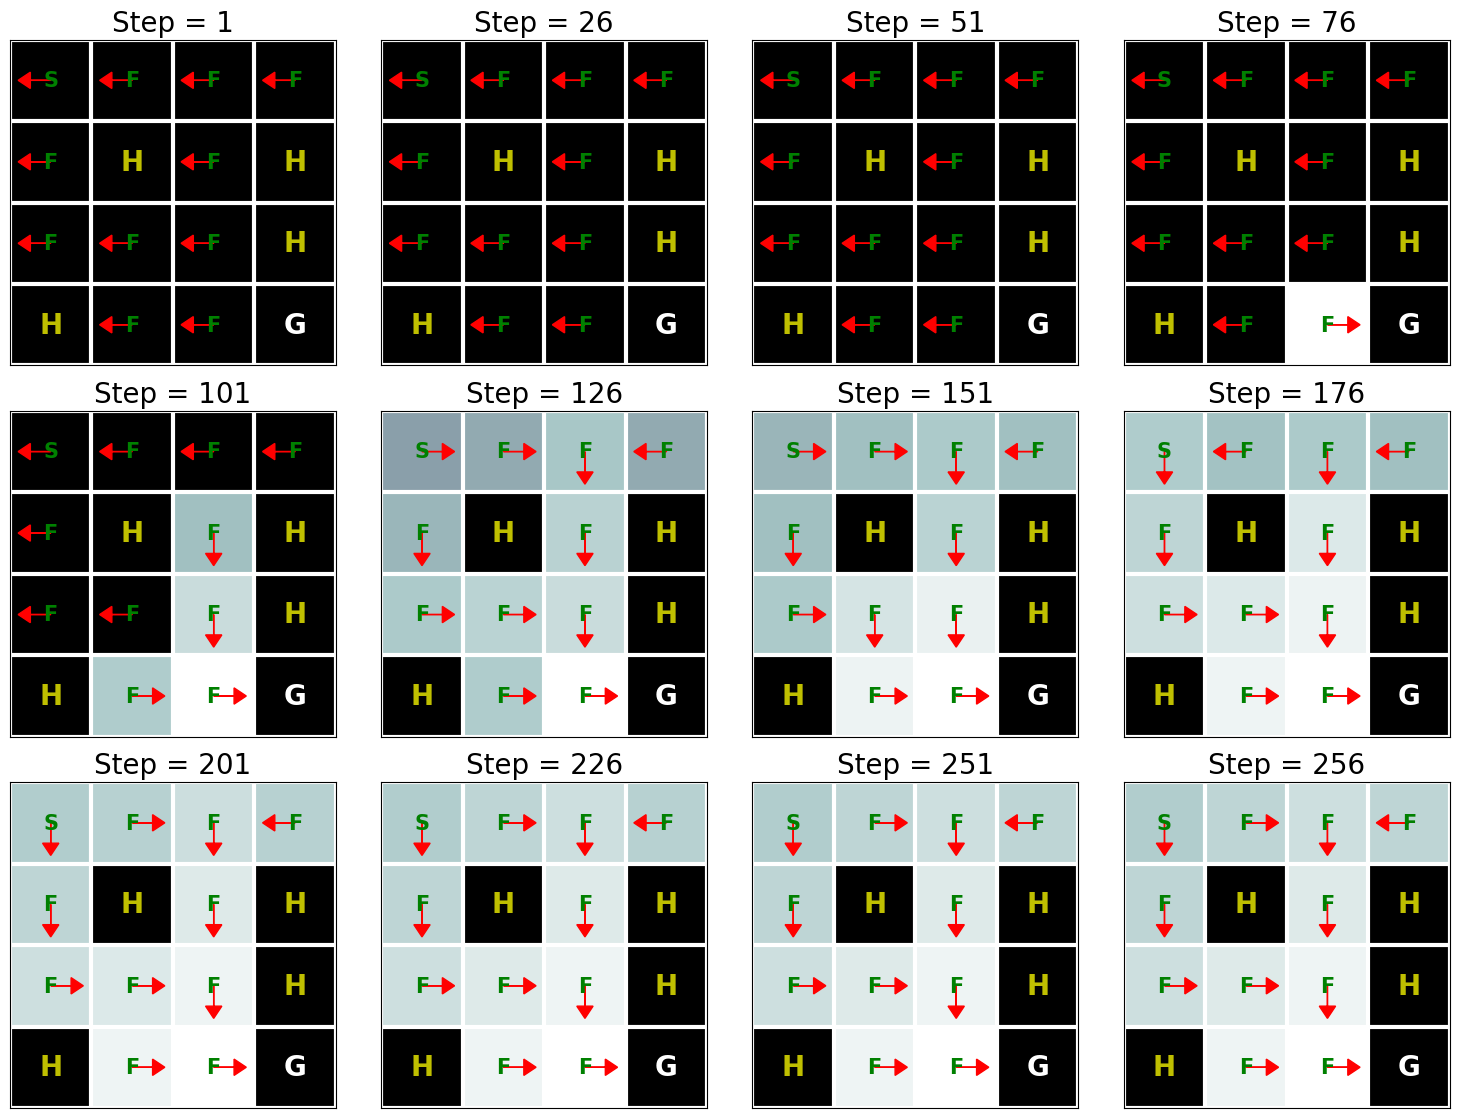

In [6]:
def q_learning(env_info, gamma, num_iters, alpha, epsilon):
    # Unlike value iteration, Q-learning does not use the transition model in updates.
    env_desc = env_info['desc']  # Grid description for plotting
    env = env_info['env']
    num_states = env_info['num_states']
    num_actions = env_info['num_actions']

    # Q is learned online from sampled transitions.
    Q = np.zeros((num_states, num_actions))
    # V and pi are tracked only for progress visualization.
    V = np.zeros((num_iters + 1, num_states))
    pi = np.zeros((num_iters + 1, num_states))

    # Each iteration runs one full episode rollout.
    for k in range(1, num_iters + 1):
        # Gymnasium reset returns (observation, info).
        state, _ = env.reset()
        done = False
        while not done:
            # Behavior policy: epsilon-greedy over current Q-values.
            action = e_greedy(env, Q, state, epsilon)
            # Gymnasium step returns (obs, reward, terminated, truncated, info).
            # Important: even with fixed (state, action), env.step returns ONE sampled
            # transition from P(s'|s,a). In this notebook is_slippery=False, so
            # FrozenLake is deterministic and that sampled next_state is effectively fixed.
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # One-step TD target (off-policy): r + gamma * max_a' Q(s', a').
            # If episode ended, there is no future return to bootstrap from.
            y = reward if done else reward + gamma * np.max(Q[next_state, :])
            # Incremental update toward the target.
            Q[state, action] = Q[state, action] + alpha * (y - Q[state, action])

            # Continue rollout from next state.
            state = next_state

        # Derive greedy value/policy snapshots from current Q for plotting.
        for s in range(num_states):
            V[k, s] = np.max(Q[s, :])
            pi[k, s] = np.argmax(Q[s, :])

    d2l.show_Q_function_progress(env_desc, V[:-1], pi[:-1])

q_learning(env_info=env_info, gamma=gamma, num_iters=num_iters, alpha=alpha, epsilon=epsilon)